In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\saurav
[nltk_data]     singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv(r"C:\ML work\dataset\Laptop_Train_v2.csv")

In [4]:
df.head()

,id,Sentence,Aspect Term,polarity,from,to
0,2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
1,2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
2,1316,The tech guy then said the service center does...,service center,negative,27,41
3,1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
4,1316,The tech guy then said the service center does...,tech guy,neutral,4,12


In [5]:
df["polarity"].value_counts()

polarity
positive    987
negative    866
neutral     460
conflict     45
Name: count, dtype: int64

In [6]:
df = df[df["polarity"] != "conflict"]

In [7]:
df["polarity"].value_counts()

polarity
positive    987
negative    866
neutral     460
Name: count, dtype: int64

In [8]:
#convertpolaritytonumber
sentiment_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["polarity"] = df["polarity"].map(sentiment_map)

In [9]:
print(df["polarity"].unique())

[1 2 0]


In [10]:
df["polarity"].value_counts()

polarity
2    987
0    866
1    460
Name: count, dtype: int64

In [11]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_Sentence"] = df["Sentence"].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to C:\Users\saurav
[nltk_data]     singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,Sentence,Aspect Term,polarity,from,to,clean_Sentence
0,2339,I charge it at night and skip taking the cord ...,cord,1,41,45,charge night skip taking cord good battery life
1,2339,I charge it at night and skip taking the cord ...,battery life,2,74,86,charge night skip taking cord good battery life
2,1316,The tech guy then said the service center does...,service center,0,27,41,tech guy said service center exchange direct c...
3,1316,The tech guy then said the service center does...,"""sales"" team",0,109,121,tech guy said service center exchange direct c...
4,1316,The tech guy then said the service center does...,tech guy,1,4,12,tech guy said service center exchange direct c...


In [12]:
#tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df["clean_Sentence"])

sequences = tokenizer.texts_to_sequences(df["clean_Sentence"])

In [13]:
#paddling
max_len = 50

X = pad_sequences(sequences, maxlen=max_len)
y = df["polarity"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))

model.add(Bidirectional(LSTM(64)))

model.add(Dense(64, activation="relu"))

model.add(Dense(3, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

c:\ML work\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.4797 - loss: 1.0200 - val_accuracy: 0.6297 - val_loss: 0.9044
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7000 - loss: 0.7075 - val_accuracy: 0.6541 - val_loss: 0.8075
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7932 - loss: 0.4899 - val_accuracy: 0.6703 - val_loss: 0.9191
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8709 - loss: 0.3408 - val_accuracy: 0.6378 - val_loss: 0.9695
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9088 - loss: 0.2518 - val_accuracy: 0.6514 - val_loss: 1.1361
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9257 - loss: 0.1981 - val_accuracy: 0.6432 - val_loss: 1.1832
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9250 - loss: 0.1751 - val_accuracy: 0.6514 - val_loss: 1.2302
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9216 - loss: 0.1627 - val_accuracy: 0.6649 -

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6674 - loss: 1.2500
Test Accuracy: 0.6673865914344788


In [18]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step


In [19]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       181
           1       0.57      0.53      0.55       114
           2       0.70      0.71      0.71       168

    accuracy                           0.67       463
   macro avg       0.65      0.65      0.65       463
weighted avg       0.67      0.67      0.67       463



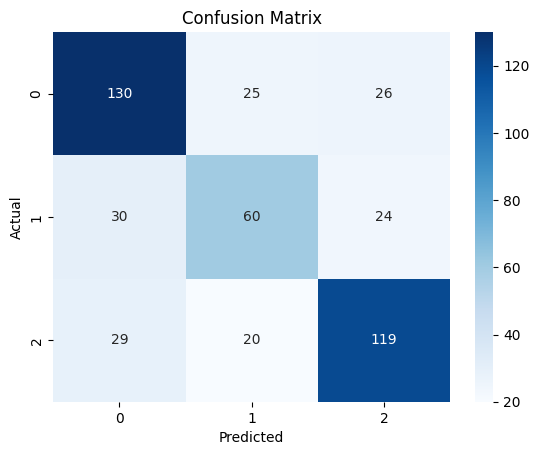

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
model.save("bilstm_absa_model.h5")

In [22]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)
    